<a href="https://colab.research.google.com/github/cconsta1/eigenvector-continuation-demo/blob/main/bose_hubbard_20260923.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: imports and global settings
import itertools, math, time
import numpy as np
import torch
from scipy.sparse.linalg import LinearOperator, eigsh, cg
from scipy.linalg import eigh
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64   # float64 keeps the higher PT orders clean; float32 is faster but noisier

L, Nb = 4, 4            # 4x4x4 periodic lattice, Nb = number of bosons
t_hop = 1.0             # hopping amplitude, sets the energy unit
mu = -6.0 * t_hop       # chemical potential, puts the U=0 ground state at E=0
print("device:", device)

device: cuda


In [ ]:
# Cell 2: periodic cubic lattice, list of nearest-neighbour bonds (each bond stored once)
def build_lattice(L):
    Ns = L**3
    idx = lambda x, y, z: (x % L)*L*L + (y % L)*L + (z % L)
    bonds = set()
    for x in range(L):
        for y in range(L):
            for z in range(L):
                i = idx(x, y, z)
                for dx, dy, dz in [(1,0,0), (0,1,0), (0,0,1)]:
                    j = idx(x+dx, y+dy, z+dz)
                    if j != i:
                        bonds.add((min(i, j), max(i, j)))
    return Ns, sorted(bonds)

Ns, bonds = build_lattice(L)
print(f"sites = {Ns}, bonds = {len(bonds)}")   # expect 64 sites, 192 bonds

sites = 64, bonds = 192


In [ ]:
# Cell 3: Fock basis for Nb bosons on Ns sites
# Each state is stored as a sorted list of the sites the bosons occupy,
# e.g. (0, 0, 5, 17) = two bosons on site 0, one on site 5, one on site 17.
# rank() maps such a list to a unique integer index (combinatorial number system),
# so no lookup table is ever needed.
Nstates = math.comb(Ns + Nb - 1, Nb)

comb_table = torch.tensor(
    [[math.comb(n, k + 1) for n in range(Ns + Nb + 1)] for k in range(Nb)],
    dtype=torch.int64, device=device)

def rank(sorted_sites):
    d = sorted_sites + torch.arange(Nb, device=device)[None, :]
    return sum(comb_table[k, d[:, k]] for k in range(Nb))

all_states = torch.tensor(
    np.fromiter(itertools.chain.from_iterable(
        itertools.combinations_with_replacement(range(Ns), Nb)),
        dtype=np.int64, count=Nstates * Nb).reshape(Nstates, Nb),
    device=device)

basis_sites = torch.empty_like(all_states)
basis_sites[rank(all_states)] = all_states      # row r of basis_sites is basis state r

print(f"Fock space dimension = {Nstates}")       # expect 766480
print("rank is a valid bijection:",
      torch.equal(torch.sort(rank(all_states)).values, torch.arange(Nstates, device=device)))

Fock space dimension = 766480
rank is a valid bijection: True


In [ ]:
# Cell 4: the two pieces of H(U) = H0 + U*H1
#   H1 (interaction) is diagonal: 1/2 * sum_i n_i (n_i - 1)
#   H0 (hopping + chemical potential): -t * sum over bonds of a_to^dag a_frm, plus the constant -mu*Nb

# H1: for each boson, count how many bosons share its site (= n_site).
# Summing (n_site - 1) over all bosons gives sum_i n_i (n_i - 1).
same_site = (basis_sites[:, :, None] == basis_sites[:, None, :]).sum(dim=2)
H1_diag = (0.5 * (same_site - 1).sum(dim=1)).to(DTYPE)
del same_site

# Hopping: for every bond and both directions, find the states with a boson on 'frm',
# move one boson to 'to', and record (source index, destination index, amplitude).
# amplitude = -t * sqrt(n_frm) * sqrt(n_to + 1)
hop_src, hop_dst, hop_amp = [], [], []
for (i, j) in bonds:
    for frm, to in [(i, j), (j, i)]:
        src = torch.nonzero((basis_sites == frm).any(dim=1), as_tuple=True)[0]
        s = basis_sites[src]
        pos = torch.argmax((s == frm).to(torch.int64), dim=1)     # pick one boson on 'frm'
        new = s.clone()
        new[torch.arange(len(src), device=device), pos] = to
        new, _ = torch.sort(new, dim=1)
        n_frm = (s == frm).sum(dim=1).to(DTYPE)
        n_to_after = (new == to).sum(dim=1).to(DTYPE)             # = n_to + 1
        hop_src.append(src)
        hop_dst.append(rank(new))
        hop_amp.append(-t_hop * torch.sqrt(n_frm * n_to_after))

print("nonzero hopping entries:", sum(len(x) for x in hop_src))

nonzero hopping entries: 17571840


In [ ]:
# Cell 5: matrix-free H(U) @ v, and the exact ground state solver (Lanczos via eigsh)
const = -mu * Nb                         # chemical potential term, identical for every state

def make_matvec(U):
    diag = U * H1_diag + const
    def matvec(v_np):
        v = torch.as_tensor(v_np, dtype=DTYPE, device=device).reshape(-1)
        out = diag * v
        for src, dst, amp in zip(hop_src, hop_dst, hop_amp):
            out.index_add_(0, dst, amp * v[src])
        return out.cpu().numpy().astype(np.float64)
    return matvec

def exact_ground_state(U):
    H = LinearOperator((Nstates, Nstates), matvec=make_matvec(U), dtype=np.float64)
    evals, evecs = eigsh(H, k=1, which="SA", tol=1e-10)
    return evals[0], evecs[:, 0]

E_check, _ = exact_ground_state(0.0)
print("E0 at U=0 (should be ~0):", E_check)

E0 at U=0 (should be ~0): -2.8777224404959688e-15


In [ ]:
# Cell 6: exact reference energies across the coupling range (one Lanczos solve per point)
U_range = np.arange(-5.0, 2.01, 0.5)
exact_energies = []
for U in U_range:
    t0 = time.time()
    E0, _ = exact_ground_state(U)
    exact_energies.append(E0)
    print(f"U/t = {U:5.2f}   E0/t = {E0:9.4f}   ({time.time() - t0:.1f} s)")

U/t = -5.00   E0/t =   -7.7125   (6.2 s)
U/t = -4.50   E0/t =   -4.9427   (8.1 s)
U/t = -4.00   E0/t =   -2.2686   (9.4 s)
U/t = -3.50   E0/t =   -0.5575   (7.3 s)
U/t = -3.00   E0/t =   -0.4118   (6.4 s)
U/t = -2.50   E0/t =   -0.3154   (5.1 s)
U/t = -2.00   E0/t =   -0.2351   (4.7 s)
U/t = -1.50   E0/t =   -0.1655   (6.0 s)
U/t = -1.00   E0/t =   -0.1041   (4.7 s)
U/t = -0.50   E0/t =   -0.0493   (5.3 s)
U/t =  0.00   E0/t =    0.0000   (6.8 s)
U/t =  0.50   E0/t =    0.0447   (4.8 s)
U/t =  1.00   E0/t =    0.0854   (6.1 s)
U/t =  1.50   E0/t =    0.1226   (4.7 s)
U/t =  2.00   E0/t =    0.1568   (5.7 s)


In [ ]:
# Cell 7: eigenvector continuation
# 1) exact ground states at a few sample couplings
# 2) project H0 and H1 onto their span ONCE:  N = V^T V,  A = V^T H0 V,  B = V^T H1 V
# 3) for any U, solve the small generalized problem (A + U B) a = E N a
U_range = np.arange(-5.0, 2.01, 0.5)
U_sample = [-5.0, -1.5, 2.0]                    # same sample points as the paper, Fig. 1a
samples = [exact_ground_state(U) for U in U_sample]
E_sample = [E for E, _ in samples]
V = np.stack([v for _, v in samples], axis=1)   # shape (Nstates, K)

H0_mv = make_matvec(0.0)                        # H(0) = H0
H1_np = H1_diag.cpu().numpy().astype(np.float64)

N_ec = V.T @ V
A_ec = V.T @ np.stack([H0_mv(V[:, k]) for k in range(V.shape[1])], axis=1)
A_ec = 0.5 * (A_ec + A_ec.T)                    # remove rounding asymmetry
B_ec = V.T @ (H1_np[:, None] * V)

def ec_energy(U):
    return eigh(A_ec + U * B_ec, N_ec, eigvals_only=True)[0]

ec_energies = [ec_energy(U) for U in U_range]
for U, E in zip(U_sample, E_sample):
    print(f"sample U/t = {U:5.2f}:  exact {E:.6f}   EC {ec_energy(U):.6f}")   # should agree

sample U/t = -5.00:  exact -7.712491   EC -7.712491
sample U/t = -1.50:  exact -0.165517   EC -0.165517
sample U/t =  2.00:  exact 0.156763   EC 0.156763


In [ ]:
# Cell 8: Rayleigh-Schrodinger perturbation theory around U = 0
# Only input: the U=0 ground state psi0. Each order n is one linear solve:
#   E^(n) = <psi0| H1 |psi^(n-1)>
#   (H0 - E^(0)) |psi^(n)> = -H1 |psi^(n-1)> + sum_{k=1..n} E^(k) |psi^(n-k)>
# with every psi^(n) kept orthogonal to psi0. Solved with conjugate gradient.
H0_mv = make_matvec(0.0)
H1_np = H1_diag.cpu().numpy().astype(np.float64)

E00, psi0 = exact_ground_state(0.0)
psi0 = psi0 / np.linalg.norm(psi0)
P = lambda x: x - psi0 * (psi0 @ x)              # project out psi0
A_pt = LinearOperator((Nstates, Nstates), dtype=np.float64,
                      matvec=lambda x: P(H0_mv(P(x)) - E00 * P(x)))

max_order = 6
E_pt, psi_pt = [E00], [psi0]
for n in range(1, max_order + 1):
    E_pt.append(psi0 @ (H1_np * psi_pt[n - 1]))
    rhs = -H1_np * psi_pt[n - 1] + sum(E_pt[k] * psi_pt[n - k] for k in range(1, n + 1))
    x, info = cg(A_pt, P(rhs), rtol=1e-10, maxiter=5000)
    psi_pt.append(P(x))
    print(f"E^({n}) = {E_pt[n]: .6e}   (cg info = {info}, 0 means converged)")

print("check: E^(1) should equal N(N-1)/(2M) =", Nb * (Nb - 1) / (2 * Ns))

def pt_energy(U, order):
    return sum(E_pt[k] * U**k for k in range(order + 1))

E^(1) =  9.375000e-02   (cg info = 0, 0 means converged)
E^(2) = -9.259033e-03   (cg info = 0, 0 means converged)
E^(3) =  9.710018e-04   (cg info = 0, 0 means converged)
E^(4) = -1.179491e-04   (cg info = 0, 0 means converged)
E^(5) =  1.755122e-05   (cg info = 0, 0 means converged)
E^(6) = -3.126822e-06   (cg info = 0, 0 means converged)
check: E^(1) should equal N(N-1)/(2M) = 0.09375


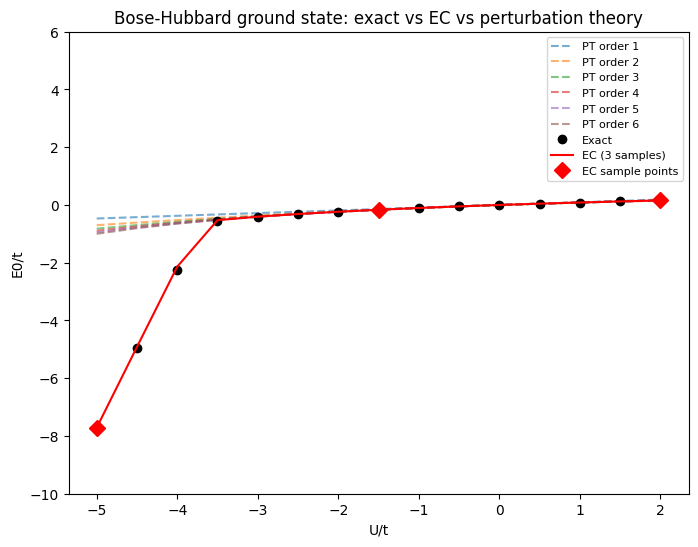

In [ ]:
# Cell 9: compare exact, EC and PT
plt.figure(figsize=(8, 6))
for order in range(1, max_order + 1):
    plt.plot(U_range, [pt_energy(U, order) for U in U_range], "--", alpha=0.6,
             label=f"PT order {order}")
plt.plot(U_range, exact_energies, "o", color="black", label="Exact")
plt.plot(U_range, ec_energies, "-", color="red", label="EC (3 samples)")
plt.plot(U_sample, E_sample, "D", color="red", markersize=8, label="EC sample points")
plt.ylim(-10, 6)
plt.xlabel("U/t"); plt.ylabel("E0/t")
plt.legend(fontsize=8)
plt.title("Bose-Hubbard ground state: exact vs EC vs perturbation theory")
plt.show()

K = 1: independent directions kept = 1
K = 2: independent directions kept = 2
K = 3: independent directions kept = 3
K = 4: independent directions kept = 3
K = 5: independent directions kept = 4


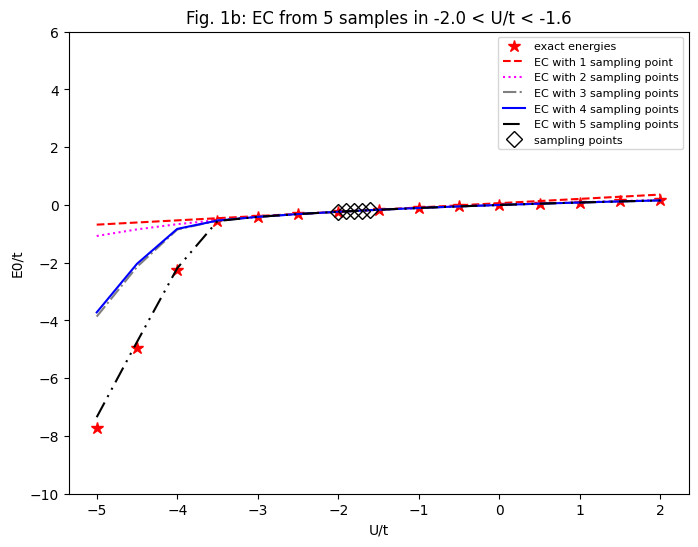

In [ ]:
# Cell 10: Fig. 1b, EC trained on a narrow window, extrapolated across the whole range
# 5 closely spaced samples in the weakly bound regime; project onto the first K = 1..5.
# The paper does not say which vectors it uses for K < 5; here we take them in order from -2.0.
U_range = np.arange(-5.0, 2.01, 0.5)
U_samples_b = [-2.0, -1.9, -1.8, -1.7, -1.6]
samples_b = [exact_ground_state(U) for U in U_samples_b]
E_samples_b = [E for E, _ in samples_b]
V_b = np.stack([v for _, v in samples_b], axis=1)            # (Nstates, 5)

# project H0, H1 and the overlap once; any K uses the top-left K x K block
H0_mv = make_matvec(0.0)
H1_np = H1_diag.cpu().numpy().astype(np.float64)
N_b = V_b.T @ V_b
A_b = V_b.T @ np.stack([H0_mv(V_b[:, k]) for k in range(V_b.shape[1])], axis=1)
A_b = 0.5 * (A_b + A_b.T)
B_b = V_b.T @ (H1_np[:, None] * V_b)

def ec_energy_K(K, U, rcond=1e-12):
    # canonical orthogonalization: drop near-parallel directions before solving
    N, H = N_b[:K, :K], A_b[:K, :K] + U * B_b[:K, :K]
    s, X = np.linalg.eigh(N)
    keep = s > rcond * s.max()
    T = X[:, keep] / np.sqrt(s[keep])
    return np.linalg.eigvalsh(T.T @ H @ T)[0], keep.sum()

for K in range(1, 6):
    print(f"K = {K}: independent directions kept = {ec_energy_K(K, 0.0)[1]}")

styles = {1: ("red", "--"), 2: ("magenta", ":"), 3: ("grey", "-."),
          4: ("blue", "-"), 5: ("black", (0, (8, 3, 1, 3, 1, 3)))}

plt.figure(figsize=(8, 6))
plt.plot(U_range, exact_energies, "*", color="red", markersize=9, label="exact energies")
for K in range(1, 6):
    color, ls = styles[K]
    plt.plot(U_range, [ec_energy_K(K, U)[0] for U in U_range], color=color, linestyle=ls,
             label=f"EC with {K} sampling point" + ("s" if K > 1 else ""))
plt.plot(U_samples_b, E_samples_b, "D", mfc="none", mec="black", markersize=8,
         label="sampling points")
plt.ylim(-10, 6)
plt.xlabel("U/t"); plt.ylabel("E0/t")
plt.legend(fontsize=8)
plt.title("Fig. 1b: EC from 5 samples in -2.0 < U/t < -1.6")
plt.show()